In [26]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import json

In [27]:
# Open json file
with open('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/Hao_data/MZB_control.json', 'r') as f:
    df_MZB_control = pd.read_json(f)

with open('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/Hao_data/MZB-Rag.json', 'r') as f:
    df_MZB_Rag= pd.read_json(f)
    
file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Ontogeny Output/DDM/T2 Precursor/DDM_T2_Division_dependent.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/emperical_fit_T2.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral1 = pkl.load(f)
else:
    raise EOFError("File is empty")


In [28]:
# Change the column names
df_MZB_control.columns = ['Weeks', 'MZB counts']
df_MZB_Rag.columns = ['Weeks', 'MZB counts']


In [29]:
#Change weeks to days
df_MZB_control['Days'] = df_MZB_control['Weeks'] * 7
df_MZB_Rag['Days'] = df_MZB_Rag['Weeks'] * 7

# Round up to integers the days
df_MZB_control['Days'] = df_MZB_control['Days'].apply(np.ceil).astype(int)
df_MZB_Rag['Days'] = df_MZB_Rag['Days'].apply(np.ceil).astype(int)

print(df_MZB_control)
print(df_MZB_Rag)


        Weeks    MZB counts  Days
0    0.029045  3.536681e+06     1
1    0.004699  4.151341e+06     1
2    0.026055  5.507860e+06     1
3    0.081583  5.901460e+06     1
4    1.185309  8.160795e+06     9
5    1.280561  7.782954e+06     9
6    1.721796  5.794672e+06    13
7    2.801602  5.885078e+06    20
8    4.136410  6.343230e+06    29
9    4.561840  6.765643e+06    32
10   4.561840  6.765643e+06    32
11  17.305946  4.111060e+06   122
12  17.283734  6.823175e+06   121
13  17.246573  7.301864e+06   121
14  30.048343  6.878401e+06   211
15  31.191793  6.897695e+06   219
16  54.401220  5.592236e+06   381
17  54.401220  5.967573e+06   381
18  54.401220  5.967573e+06   381
19  54.387125  6.609919e+06   381
20  54.738660  7.729220e+06   384
21  54.263682  7.436428e+06   380
        Weeks    MZB counts  Days
0    1.767072  6.091468e+06    13
1    2.352252  6.165507e+06    17
2    2.159613  8.218408e+06    16
3    2.204889  7.682917e+06    16
4    4.121033  8.047294e+06    29
5    3.831860 

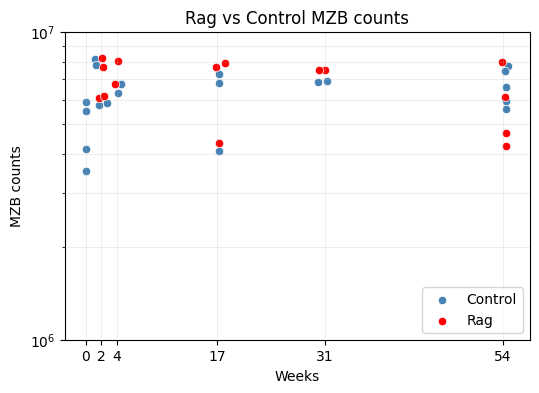

In [30]:
# Plot the data 
fig = plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_MZB_control, x='Weeks', y='MZB counts', color='steelblue', label='Control')
sns.scatterplot(data=df_MZB_Rag, x='Weeks', y='MZB counts', color='red', label='Rag')
plt.yscale('log')
# plt.xscale('log')
plt.ylim(1e6, 1e7)
# plt.yticks([1e6, 2e6, 5e6, 1e7], ['1M', '2M', '5M', '10M'])
# plt.xticks(np.arange(0, 401, 50))
# plt.xlim(0, 60)
plt.xticks([0, 2, 4, 17, 31, 54], [0, 2, 4, 17, 31, 54])
plt.xlabel('Weeks')
plt.ylabel('MZB counts')
plt.title('Rag vs Control MZB counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

In [32]:
def P(t):
    theta_0 = np.exp(np.mean(data_neutral1.theta_0))
    nu = np.mean(data_neutral1.nu)
    n = np.mean(data_neutral1.n)
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   
def b(M):
    rho = np.mean(data_neutral.rho)
    M_stable = np.mean(data_neutral.M_stable)
    K = np.mean(data_neutral.K)
    b_val =  rho /(1 - (M_stable/K))
    r_m = b_val * (1 - (M/K))
    return r_m

# Define the ODE function
def ode_function(t, M, b, delta):
    phi = (delta - rho)*M_stable
    dMdt =phi*P(t) - ( delta - b(M)) * M
    return dMdt  # Ensure the return value matches the shape of M

delta = np.mean(data_neutral.delta)#Death rate
rho = np.mean(data_neutral.rho)
M_stable = np.mean(data_neutral.M_stable)
#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [4.151341e+06]
M1 = [6.091468e+06]

t_ev = np.arange(1, 400, 0.001)
t_ev1 = np.arange(13, 400, 0.001)

sol = solve_ivp(ode_function, [1, 400], M0, t_eval=t_ev, args=(b, delta))
print(sol.y)

# sol1 = solve_ivp(ode_function, [13, 400], M1, t_eval=t_ev1, args=(b, delta))
# print(sol1.y)

# sol = np.zeros((len(data_neutral.phi), len(t_ev)))
# for i in range(len(data_neutral.phi)):
#     result = solve_ivp(ode_function, [40, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P))
#     sol[i, :] = result.y[0]

# print(sol.shape)
# print(M0)



/tmp/ipykernel_3081170/2716812220.py:5: RuntimeWarning: invalid value encountered in scalar power
  return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


KeyboardInterrupt: 

/tmp/ipykernel_3429322/1719167946.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 500)


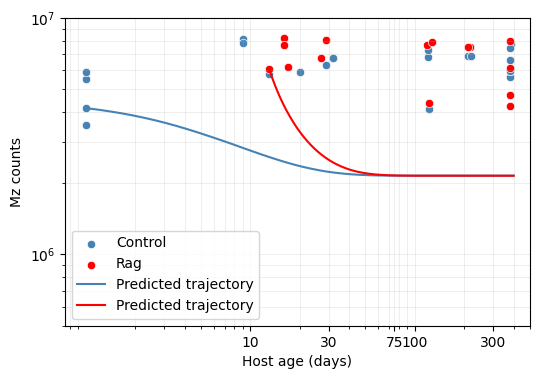

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_MZB_control, x='Days', y='MZB counts', color='steelblue', label='Control')
sns.scatterplot(data=df_MZB_Rag, x='Days', y='MZB counts', color='red', label='Rag')
plt.plot(t_ev, sol.y[0], color='steelblue',label='Predicted trajectory')
plt.plot(t_ev1, sol1.y[0], color='red',label='Predicted trajectory')
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e5, 1e7)
plt.xlim(0, 500)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300], [10, 30, 75, 100, 300])
plt.xlabel('Host age (days)')
plt.ylabel('Mz counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()